# Experiment 01 — Move matching accuracy vs Human (by rating bin)

Compute **move matching accuracy** between each model and the human move, aggregated by `rating_bin` (6 bins) plus an `ALL` row.

- Rows: rating bins + `ALL`
- Columns: `fen_{model}`
- Matching rule: `fen_{model} == fen_after` on a common eligible row mask (so denominators are the same across all models).


In [2]:
# === Imports / seeds ===
import subprocess, sys
from pathlib import Path
import re
import random

import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [ ]:
# === Paths / config ===
REPO_ROOT = "/home/jovyan/artem/chess-fraud"
print("REPO_ROOT:", REPO_ROOT)

INPUT_CSV = REPO_ROOT / Path("data/processed/chess_fraud_synth_extended.csv")
assert INPUT_CSV.exists(), f"Missing INPUT_CSV: {INPUT_CSV}"
print("INPUT_CSV:", INPUT_CSV)

OUT_DIR = REPO_ROOT / Path("reports/move_level/02_human_similarity")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

RATING_BIN_COL = "rating_bin"

# Chunk size for streaming through ~1M rows without blowing RAM.
CHUNKSIZE = 200_000


REPO_ROOT: /home/jovyan/artem/chess-fraud
INPUT_CSV: /home/jovyan/artem/chess-fraud/data/processed/chess_fraud_synth_extended.csv
OUT_DIR: /home/jovyan/artem/chess-fraud/reports/move_level/02_move_matching_accuracy_by_rating_bin


In [ ]:
# === Utilities ===
def select_eligible_rows(df: pd.DataFrame) -> pd.Series:
    """Eligibility mask (reused across experiments).

    Rule:
      half_move > 20 AND (
        (player_color == 'white' AND half_move % 2 == 1) OR
        (player_color == 'black' AND half_move % 2 == 0)
      )
    """
    half_move = df["half_move"].to_numpy()
    player_color = df["player_color"].astype("string")

    return (half_move > 20) & (
        ((player_color == "white") & (half_move % 2 == 1)) |
        ((player_color == "black") & (half_move % 2 == 0))
    )


def build_fen_col_to_model(columns: list[str]) -> dict[str, str]:
    """Map FEN columns to model names.

    Requirements:
      - fen_after -> human
      - all other fen_* (except fen_before) map by stripping 'fen_' prefix:
          fen_maia2_1850 -> maia2_1850
    """
    out: dict[str, str] = {}
    if "fen_after" in columns:
        out["fen_after"] = "human"

    for c in columns:
        if not c.startswith("fen_"):
            continue
        if c in ("fen_before", "fen_after"):
            continue
        out[c] = c.replace("fen_", "", 1)

    return out


def _model_sort_key(name: str) -> tuple:
    """Stable, human-friendly model ordering for tables/figures."""
    if name == "human":
        return (0, 0)

    m = re.match(r"^(maia1|maia2)_(\d+)$", name)
    if m:
        fam, r = m.group(1), int(m.group(2))
        return (1 if fam == "maia1" else 2, r)

    m = re.match(r"^lc0_(\d+)$", name)
    if m:
        return (3, int(m.group(1)))

    m = re.match(r"^stockfish_(\d+)$", name)
    if m:
        return (4, int(m.group(1)))

    return (5, name)


def _rating_bin_sort_key(b: str) -> tuple:
    """Sort keys like: lt_1000, 1000_1100, ..., 1900_2000, gt_2000."""
    if b == "ALL":
        return (10**9, 10**9, b)

    m = re.match(r"^lt_(\d+)$", b)
    if m:
        return (-1, int(m.group(1)), b)

    m = re.match(r"^(\d+)_(\d+)$", b)
    if m:
        return (int(m.group(1)), int(m.group(2)), b)

    m = re.match(r"^gt_(\d+)$", b)
    if m:
        return (10**8, int(m.group(1)), b)

    return (10**7, 10**7, b)


def plot_agreement_heatmap(
    agreement: pd.DataFrame,
    *,
    title: str | None = None,
    out_path: Path | None = None,
    figsize: tuple[int, int] | None = None,
    show_values: bool = True,
) -> None:
    """Heatmap with standard white background + black labels.

    Works for both square and rectangular tables.
    Values are rendered as integer percents (e.g. 0.81 -> 81).
    """
    n_rows, n_cols = agreement.shape
    if figsize is None:
        w = min(24, max(8, int(0.55 * n_cols)))
        h = min(18, max(6, int(0.45 * n_rows)))
        figsize = (w, h)

    mat = agreement.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    _im = ax.imshow(
        mat,
        vmin=0.0,
        vmax=1.0,
        cmap="Blues",
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(agreement.columns.tolist(), rotation=45, ha="right", color="black")
    ax.set_yticklabels(agreement.index.tolist(), color="black")
    ax.tick_params(axis="both", colors="black", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    if title:
        ax.set_title(title, color="black", pad=10)

    if show_values:
        for i in range(n_rows):
            for j in range(n_cols):
                v = mat[i, j]
                if not np.isfinite(v):
                    continue
                p = int(round(v * 100))
                txt = str(p)
                ax.text(
                    j, i, txt,
                    ha="center", va="center",
                    fontsize=8,
                    color=("white" if v >= 0.6 else "black"),
                )

    fig.tight_layout(pad=0.6)
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()


In [5]:
# === Model-vs-human accuracy by rating bin ===
def model_vs_human_accuracy_by_bin_from_csv(
    input_csv: Path,
    *,
    rating_bin_col: str,
    chunksize: int,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Compute per-bin move matching accuracy between each model and human.

    Matching rule (per row): fen_{model} == fen_after

    Denominator per bin is *common across all models*:
      eligible_rows AND non-null across [rating_bin, fen_after, all model fen_* cols].

    Returns:
      acc_df: index=rating bins (+ ALL), columns=models, values in [0,1]
      mapping_df: fen_col -> model (model order matches acc_df columns + human)
      denom_df: index=rating bins (+ ALL), denom counts (eligible rows used)
    """
    header_cols = pd.read_csv(input_csv, nrows=0).columns.tolist()

    # Required columns
    for c in ("half_move", "player_color", rating_bin_col, "fen_after"):
        if c not in header_cols:
            raise ValueError(f"Missing required column: {c}")

    fen_col_to_model = build_fen_col_to_model(header_cols)

    # All available fen cols (including fen_after) in stable order
    fen_cols_all = [c for c in fen_col_to_model.keys() if c in header_cols]
    if "fen_after" not in fen_cols_all:
        raise ValueError("Expected 'fen_after' to exist in the CSV for human move.")

    pairs = [(c, fen_col_to_model[c]) for c in fen_cols_all]
    pairs.sort(key=lambda x: _model_sort_key(x[1]))

    fen_cols_all = [c for c, m in pairs]
    model_names_all = [m for c, m in pairs]  # includes 'human'

    # Split out models (exclude human)
    model_fen_cols = [c for c, m in pairs if m != "human"]
    model_names = [m for c, m in pairs if m != "human"]

    if len(model_fen_cols) == 0:
        raise ValueError("No model fen_* columns found (besides fen_after/human).")

    usecols = ["half_move", "player_color", rating_bin_col, "fen_after"] + model_fen_cols

    # Accumulators
    matches_by_bin: dict[str, np.ndarray] = {}
    denom_by_bin: dict[str, int] = {}

    total_matches = np.zeros(len(model_names), dtype=np.int64)
    total_denom = 0

    it = pd.read_csv(input_csv, usecols=usecols, chunksize=chunksize)
    pbar = tqdm(it, desc="Scan CSV chunks", unit="chunk") if verbose else it

    for chunk in pbar:
        mask = select_eligible_rows(chunk) & chunk[rating_bin_col].notna()
        if not mask.any():
            continue

        sub = chunk.loc[mask, [rating_bin_col, "fen_after"] + model_fen_cols]

        # Common non-null mask so denom is identical across models
        nn = sub.notna().all(axis=1)
        if not nn.any():
            continue
        sub = sub.loc[nn]

        # Group by rating bin within the chunk
        for b, g in sub.groupby(rating_bin_col, sort=False):
            b = str(b)
            human = g["fen_after"].to_numpy(dtype=object, copy=False)
            models = g[model_fen_cols].to_numpy(dtype=object, copy=False)

            eq = (models == human[:, None])
            msum = eq.sum(axis=0, dtype=np.int64)
            d = len(g)

            if b not in matches_by_bin:
                matches_by_bin[b] = np.zeros(len(model_names), dtype=np.int64)
                denom_by_bin[b] = 0

            matches_by_bin[b] += msum
            denom_by_bin[b] += d

            total_matches += msum
            total_denom += d

    bins_sorted = sorted(matches_by_bin.keys(), key=_rating_bin_sort_key)

    # Build accuracy table
    rows = []
    idx = []
    denoms = []

    for b in bins_sorted:
        d = denom_by_bin[b]
        if d <= 0:
            continue
        acc = matches_by_bin[b].astype(np.float64) / float(d)
        rows.append(acc)
        idx.append(b)
        denoms.append(d)

    # ALL row
    acc_all = total_matches.astype(np.float64) / float(total_denom)
    rows.append(acc_all)
    idx.append("ALL")
    denoms.append(int(total_denom))

    acc_df = pd.DataFrame(np.vstack(rows), index=idx, columns=model_names)

    mapping_df = pd.DataFrame(
        {"fen_col": fen_cols_all, "model": model_names_all}
    )

    denom_df = pd.DataFrame({"denom": denoms}, index=idx)

    return acc_df, mapping_df, denom_df


In [6]:
# === Run ===
acc_df, mapping_df, denom_df = model_vs_human_accuracy_by_bin_from_csv(
    INPUT_CSV,
    rating_bin_col=RATING_BIN_COL,
    chunksize=CHUNKSIZE,
    verbose=True,
)

display(mapping_df)
display(denom_df)
display(acc_df)


Scan CSV chunks: 6chunk [01:13, 12.28s/chunk]


,fen_col,model
0,fen_after,human
1,fen_maia1_1100,maia1_1100
2,fen_maia1_1200,maia1_1200
3,fen_maia1_1300,maia1_1300
4,fen_maia1_1400,maia1_1400
5,fen_maia1_1500,maia1_1500
6,fen_maia1_1600,maia1_1600
7,fen_maia1_1700,maia1_1700
8,fen_maia1_1800,maia1_1800
9,fen_maia1_1900,maia1_1900


,denom
lt_1200,66926
1200-1400,69222
1400-1600,68664
1600-1800,69815
1800-2000,70763
2000-2200,71817
ALL,417207


,maia1_1100,maia1_1200,maia1_1300,maia1_1400,maia1_1500,maia1_1600,maia1_1700,maia1_1800,maia1_1900,maia2_1050,...,character_Odirovski_2499,character_Quillotamaster_2405,character_Smalldoc_2254,character_alkhawaja111_2217,character_fuegodejavu_2215,character_jozarov_2323,character_lindenice_2272,character_nrm18_2369,character_oberschlumpf_2261,character_rmnp_2284
lt_1200,0.484356,0.483878,0.485103,0.481442,0.478364,0.472895,0.469205,0.463407,0.459672,0.515853,...,0.420957,0.421092,0.438021,0.442384,0.441368,0.435645,0.434241,0.433329,0.436960,0.433972
1200-1400,0.493528,0.496388,0.500404,0.499003,0.498729,0.495767,0.489917,0.486926,0.484138,0.524833,...,0.439311,0.438257,0.458438,0.461934,0.458265,0.456733,0.450522,0.452515,0.457730,0.450666
1400-1600,0.493679,0.496985,0.500845,0.502520,0.502971,0.501777,0.498515,0.496170,0.489907,0.520578,...,0.442823,0.446784,0.466256,0.465834,0.464567,0.460518,0.455421,0.455945,0.461115,0.457066
1600-1800,0.492015,0.499277,0.505078,0.508530,0.514503,0.512082,0.512569,0.509418,0.505579,0.524214,...,0.453269,0.454473,0.475514,0.477906,0.473480,0.474010,0.465273,0.468982,0.469154,0.469799
1800-2000,0.481226,0.487783,0.497138,0.503766,0.509659,0.510026,0.512923,0.512118,0.509998,0.515495,...,0.456425,0.460961,0.478640,0.480025,0.477269,0.475941,0.471673,0.470006,0.474782,0.473044
2000-2200,0.471685,0.477477,0.485762,0.494270,0.502402,0.504059,0.510241,0.512177,0.514084,0.502318,...,0.462453,0.462718,0.479664,0.478759,0.477686,0.479218,0.473607,0.473913,0.479176,0.478188
ALL,0.485982,0.490248,0.495730,0.498352,0.501286,0.499663,0.499201,0.497058,0.494292,0.517129,...,0.446167,0.447682,0.466387,0.468077,0.465704,0.463993,0.458746,0.459407,0.463451,0.460776


Saved: /home/jovyan/artem/chess-fraud/reports/move_level/02_move_matching_accuracy_by_rating_bin/tables/move_matching_accuracy_vs_human_by_rating_bin.csv
Saved: /home/jovyan/artem/chess-fraud/reports/move_level/02_move_matching_accuracy_by_rating_bin/tables/fen_col_to_model.csv
Saved: /home/jovyan/artem/chess-fraud/reports/move_level/02_move_matching_accuracy_by_rating_bin/tables/denom_by_rating_bin.csv


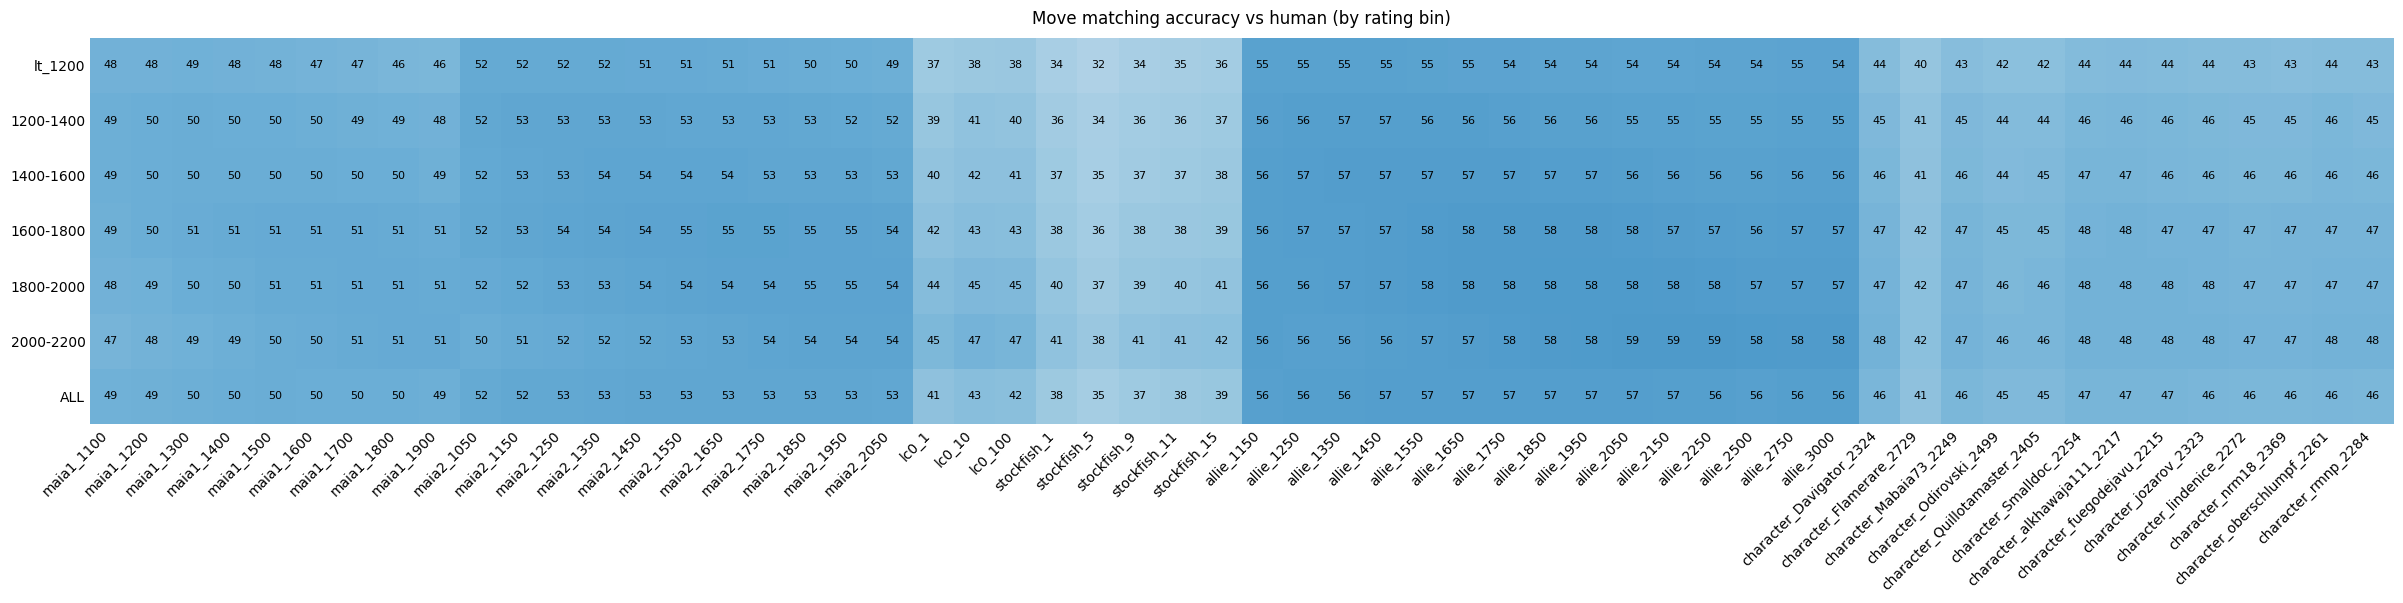

Saved: /home/jovyan/artem/chess-fraud/reports/move_level/02_move_matching_accuracy_by_rating_bin/plots/move_matching_accuracy_vs_human_by_rating_bin_heatmap.png


In [ ]:
# === Save + plot ===
OUT_CSV = OUT_DIR / "tables" / "move_matching_accuracy_vs_human_by_rating_bin.csv"
OUT_MAP = OUT_DIR / "tables" / "fen_col_to_model.csv"
OUT_DEN = OUT_DIR / "tables" / "denom_by_rating_bin.csv"
OUT_PNG = OUT_DIR / "figures" / "move_matching_accuracy_vs_human_by_rating_bin_heatmap.png"

acc_df.to_csv(OUT_CSV, index=True)
mapping_df.to_csv(OUT_MAP, index=False)
denom_df.to_csv(OUT_DEN, index=True)

print("Saved:", OUT_CSV)
print("Saved:", OUT_MAP)
print("Saved:", OUT_DEN)

plot_agreement_heatmap(
    acc_df,
    title="Move matching accuracy vs human (by rating bin)",
    out_path=OUT_PNG,
    show_values=True,
)
print("Saved:", OUT_PNG)
